In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Our modules
from src.data_loader import load_data
from src.cleaning import remove_nulls, normalize_timezone
from src.indicators import add_all_indicators
from src.sentiment import aggregate_daily_sentiment
from src.sentiment import add_sentiment_scores


plt.style.use('seaborn-v0_8')
%matplotlib inline

In [2]:
# Load News Data
news = load_data('../data/raw/news.csv', index_col=0, parse_dates=['date'])
news = normalize_timezone(news, 'date')
news = remove_nulls(news)

print("News shape:", news.shape)
print("Date range:", news['date'].min(), "to", news['date'].max())

# Load Stock Data - META
stock = load_data('../data/raw/stockData/META.csv', 
                  index_col='Date', 
                  parse_dates=True)

print("Stock shape:", stock.shape)
print("Stock date range:", stock.index.min(), "to", stock.index.max())

News shape: (1407328, 5)
Date range: 2009-02-14 00:00:00+00:00 to 2020-06-11 21:12:35+00:00
Stock shape: (2923, 5)
Stock date range: 2012-05-18 00:00:00 to 2023-12-29 00:00:00


In [3]:
# Add all indicators
stock = add_all_indicators(stock)

# Show latest rows
stock[['Close', 'SMA_20', 'RSI', 'BB_Upper', 'BB_Lower', 'Daily_Return']].tail()

,Close,SMA_20,RSI,BB_Upper,BB_Lower,Daily_Return
Date,,,,,,
2023-12-22,351.224823,332.302945,67.333885,354.085026,310.520864,-0.197681
2023-12-26,352.655975,333.303278,68.187000,356.825215,309.781340,0.407475
2023-12-27,355.637543,334.239505,69.947874,359.674389,308.804621,0.845461
2023-12-28,356.124634,335.537503,70.237702,362.605290,308.469716,0.136963
2023-12-29,351.791290,336.869788,64.296803,364.379857,309.359718,-1.216805


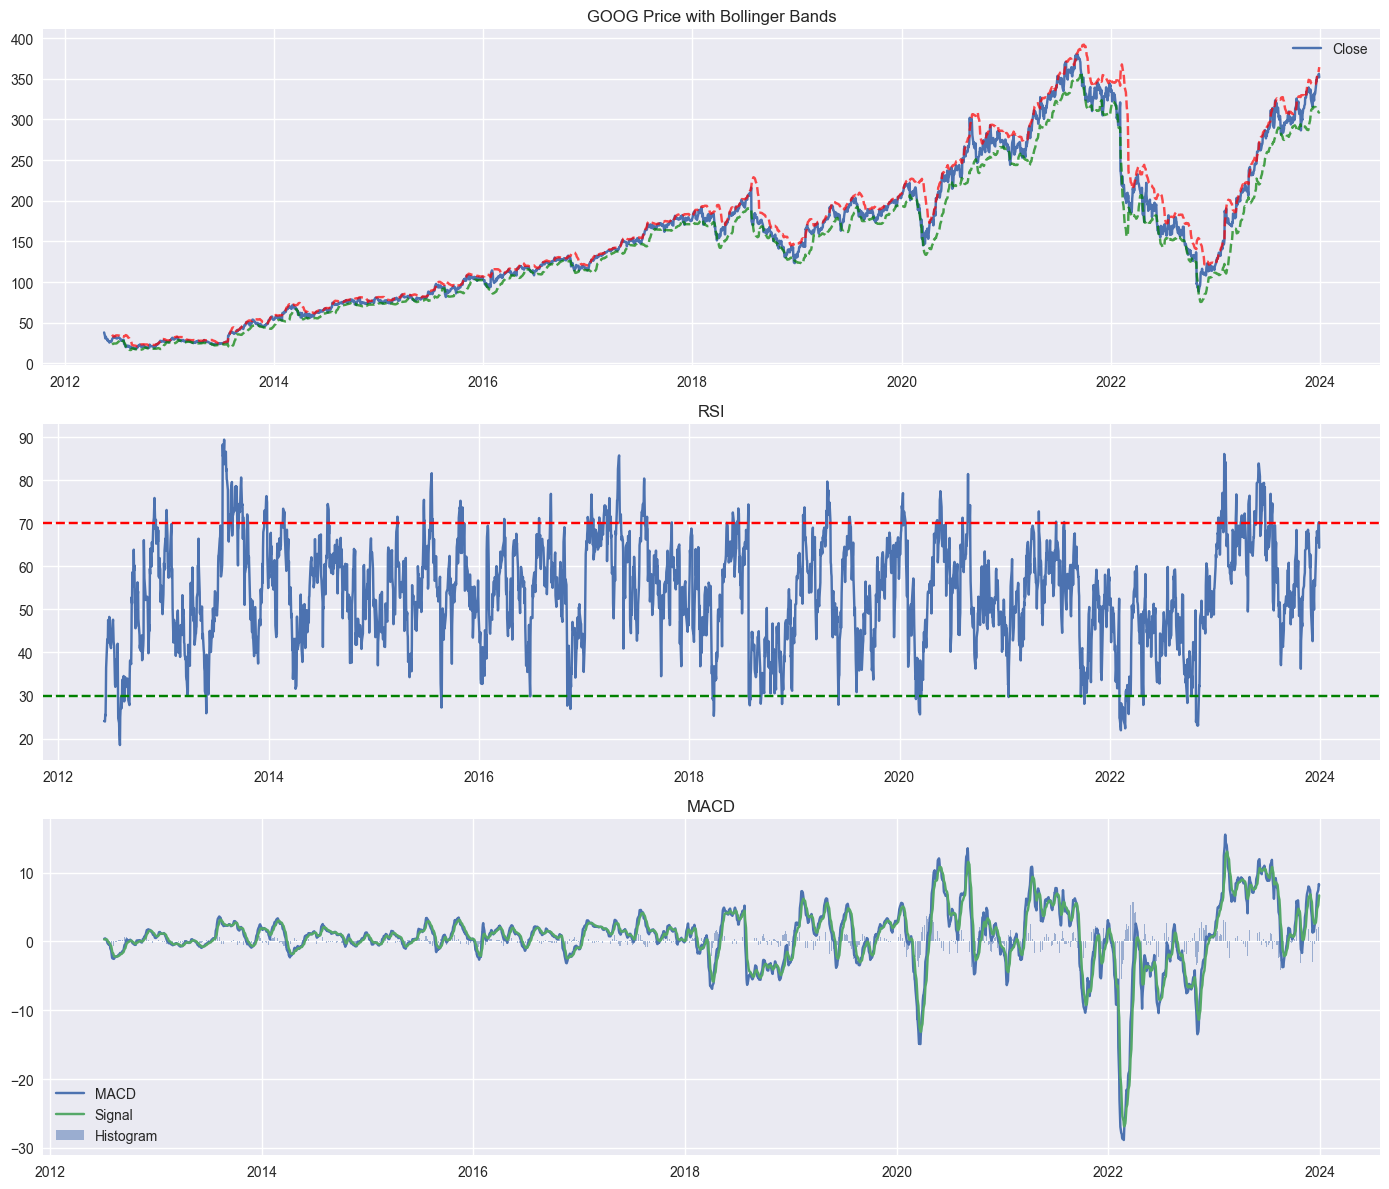

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Price + Bollinger Bands
axes[0].plot(stock.index, stock['Close'], label='Close')
axes[0].plot(stock.index, stock['BB_Upper'], 'r--', alpha=0.7)
axes[0].plot(stock.index, stock['BB_Lower'], 'g--', alpha=0.7)
axes[0].set_title('GOOG Price with Bollinger Bands')
axes[0].legend()

# RSI
axes[1].plot(stock.index, stock['RSI'])
axes[1].axhline(70, color='r', linestyle='--')
axes[1].axhline(30, color='g', linestyle='--')
axes[1].set_title('RSI')

# MACD
axes[2].plot(stock.index, stock['MACD'], label='MACD')
axes[2].plot(stock.index, stock['Signal'], label='Signal')
axes[2].bar(stock.index, stock['Histogram'], label='Histogram', alpha=0.5)
axes[2].set_title('MACD')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Get daily sentiment for META
daily_sentiment = aggregate_daily_sentiment(news, 'META')

print("Daily sentiment shape:", daily_sentiment.shape)
daily_sentiment.head()

No news found for ticker: META
Daily sentiment shape: (0, 0)


""


In [ ]:
goog_news = news[news['stock'] == 'GOOG'].copy()
print("Rows for GOOG:", len(goog_news))
print("Null headlines:", goog_news['headline'].isna().sum())
print(goog_news['headline'].head(10))